# IIA 2024 - Aprendizaje Automatizado

## Introducción a Jupyter Notebooks y Generación de Datos

## Bertoni Juan Ignacio, Goñi Martín y Wasserstrom Lucas Nicolas

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from typing import Tuple

## Diagonales

Generar n datos con d inputs:

  - n/2 pertenecientes a la categoría 0. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (-1, -1, -1, ... , -1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).
  - n/2 pertenecientes a la categoría 1. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (1, 1, 1, ... ,1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).


In [123]:
def diagonales(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera sampleos de dos gausianas d-dimensionales en posición diagonal
    (una respecto a la otra), con dispersión C * sqrt(d).
    Cada sampleo posee n/2 puntos.

    Argumentos:
        d: número de dimensiones
        C: constante de ajuste de dispersión
        n: número de ejemplos a generar

    Retorna:
        X: matriz con d columnas y n filas de datos
        y: arreglo de n elementos con las clases correspondientes
            a cada fila de datos
    """    
    # Start rng generator.
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation.
    s_d = C * np.sqrt(d)

    class_1_center = np.ones(d)
    class_0_center = (-1) * np.ones(d)

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y

Verificamos ahora los datos generados, mostrándolos con matplotlib.pyplot

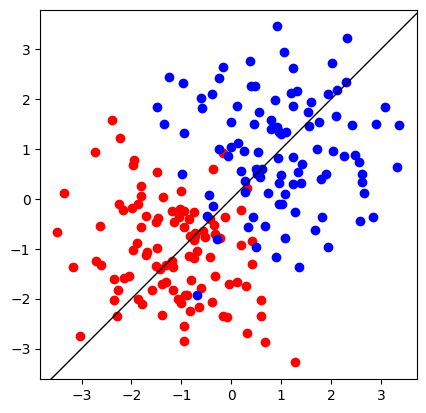

In [141]:
diag_X, diag_y = diagonales(2, 0.75, 200)

mask_0 = diag_y == 0
mask_1 = diag_y == 1

plt.close()
plt.gca().set_aspect('equal')
plt.axline((1, 1), slope=1, color='black', linewidth=1)
plt.scatter(diag_X[mask_0][:, 0], diag_X[mask_0][:, 1], color='red', label='Class 0')
plt.scatter(diag_X[mask_1][:, 0], diag_X[mask_1][:, 1], color='blue', label='Class 1')
plt.show()

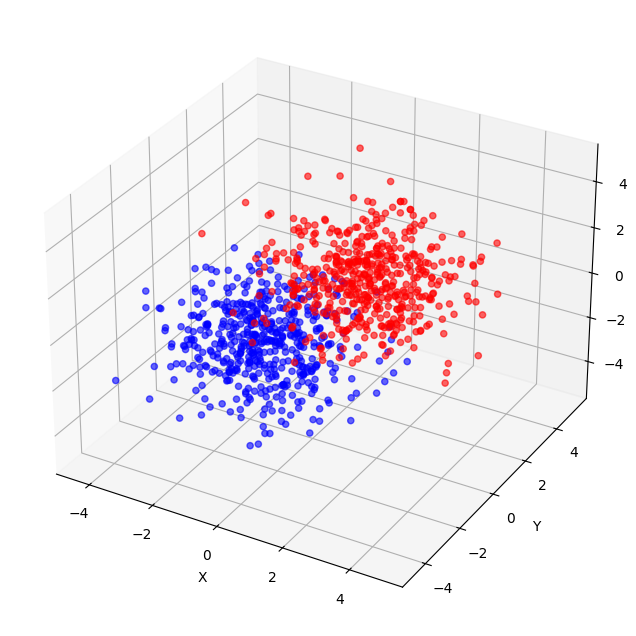

In [125]:
diag_X, diag_y = diagonales(3, 0.75, 1000)

plt.close()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(diag_X[diag_y == 0, 0], diag_X[diag_y == 0, 1], diag_X[diag_y == 0, 2], c='blue', label='Class 0', alpha=0.6)
ax.scatter(diag_X[diag_y == 1, 0], diag_X[diag_y == 1, 1], diag_X[diag_y == 1, 2], c='red', label='Class 1', alpha=0.6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

## Paralelas

Igual al punto anterior, pero las distribuciones tienen centro en el ( 1, 0, 0, .... , 0 ) y en el ( -1, 0, 0, .... , 0 ), respectivamente y la desviación estandar es igual a C independientemente de d.

In [126]:
def paralelas(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    # Start rng generator.
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation.
    s_d = C * np.sqrt(d)

    z_a = np.zeros(d - 1)
    class_1_center = np.concatenate(([1], z_a))
    class_0_center = np.concatenate(([-1], z_a))

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y 

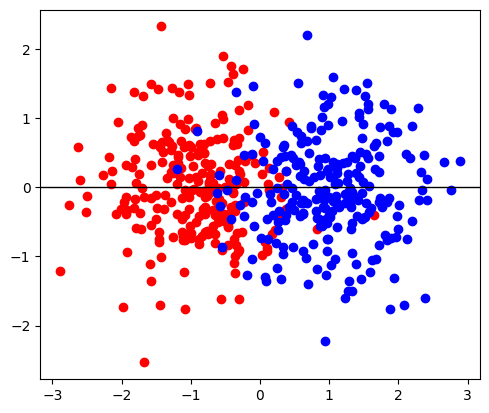

In [134]:
diag_X, diag_y = paralelas(2, 0.5, 500)

mask_0 = diag_y == 0
mask_1 = diag_y == 1

plt.close()
plt.gca().set_aspect('equal')
plt.axhline(0, color='black', linewidth=1)
plt.scatter(diag_X[mask_0][:, 0], diag_X[mask_0][:, 1], color='red', label='Class 0')
plt.scatter(diag_X[mask_1][:, 0], diag_X[mask_1][:, 1], color='blue', label='Class 1')
plt.show()

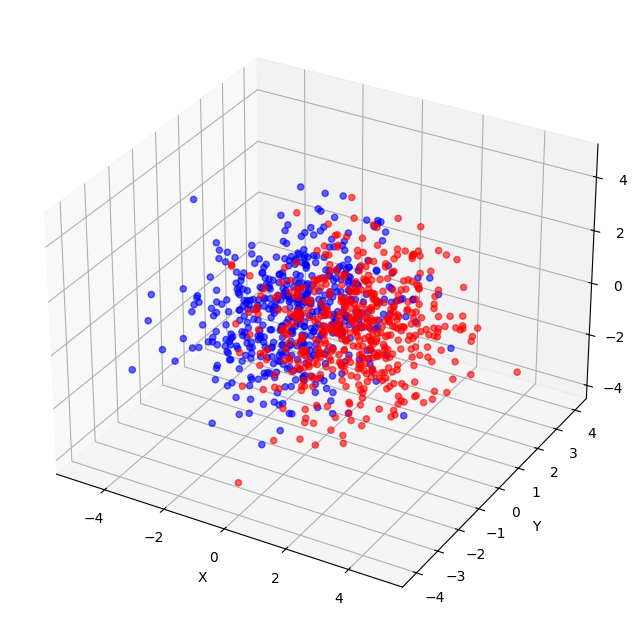

In [128]:
para_X, para_y = paralelas(3, 0.75, 1000)

plt.close()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(para_X[para_y == 0, 0], para_X[para_y == 0, 1], para_X[para_y == 0, 2], c='blue', label='Class 0', alpha=0.6)
ax.scatter(para_X[para_y == 1, 0], para_X[para_y == 1, 1], para_X[para_y == 1, 2], c='red', label='Class 1', alpha=0.6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

## Espirales

Generar n datos. De los n puntos generados, n/2 deben pertenecer a cada clase.

Los datos tienen 2 inputs, x e y, que corresponden a puntos generados al azar con una distribución UNIFORME (en dicho sistema de referencia x-y) dentro de un circulo de radio 1.

El output es binario, correspondiendo la clase 0 a los puntos que se encuentran entre las curvas ro = theta/4pi y ro = (theta + pi)/4pi (en polares) y la clase 1 al resto.

In [129]:
def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng()
    c_0 = []
    c_1 = []

    for _ in range(n):
        # Generate point inside a circle of radius 1.
        r = np.sqrt(rng.uniform(low=0, high=1))
        a = rng.uniform(low=0, high=1) * 2 * np.pi
        
        appended = False

        # Classify point.
        for step in range(3):
            p1 = step * 2 * np.pi
            p2 = step * 2 * np.pi - 2 * np.pi
            r1 = (p1 + a) / (4 * np.pi)
            r2 = (p2 + a + np.pi) / (4 * np.pi)

            # Calculate quadrant of angle.
            qa = np.mod(a, 2 * np.pi)
            quadrant = int((qa // (np.pi/2)) + 1)
            # Check if point is inside curve, the quadrant check is done because of the change in signs.
            if quadrant <= 2 and r >= r1 and r <= r2:
                appended = True
                c_0.append([r * np.cos(a), r * np.sin(a)])
                break
            elif r <= r1 and r >= r2:
                appended = True
                c_0.append([r * np.cos(a), r * np.sin(a)])
                break

        # Point is outside curve.
        if not appended:
            c_1.append([r * np.cos(a), r * np.sin(a)])

    return (np.array(c_0).T, np.array(c_1).T)

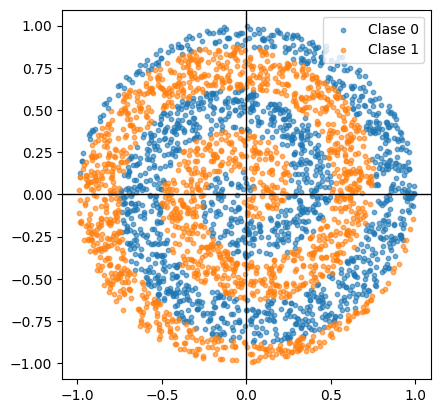

In [139]:
(c_0, c_1) = espirales(3000)

plt.close()
# Preserve 1:1 aspect ratio.
plt.gca().set_aspect('equal')
plt.axvline(0, color='black', linewidth=1)
plt.axhline(0, color='black', linewidth=1)
plt.scatter(c_0[0, :], c_0[1, :], label='Clase 0', alpha=0.6, s=10, color="tab:blue")
plt.scatter(c_1[0, :], c_1[1, :], label='Clase 1', alpha=0.6, s=10, color="tab:orange")
plt.legend()
plt.show()


### 